In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
NumPy: 2.0.2
Pandas: 2.3.3
Matplotlib: 3.9.4
Scikit-learn: 1.6.1


In [2]:
import pandas as pd

MY_ID = 2729
raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=MY_ID)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print("Формат таблицы:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропущенные значения (NaN):")
print(df.isna().sum())
print("\nСтатистика по столбцам:")
print(df.describe(include="all").T)

Формат таблицы: (1152, 11)

Типы данных:
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object

Пропущенные значения (NaN):
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           58
building_type         0
ceiling_height_m    132
price_kzt             0
dtype: int64

Статистика по столбцам:
                   count unique         top freq         mean        std  min  \
listing_id          1152   1080   ALM-10003    3          NaN        NaN  NaN   
listed_date         1152    246  2026-04-21   11          NaN        NaN  NaN   
district            1152     48       Medeu  142          NaN  

In [3]:
# 1. duplicates
exact_duplicates = df.duplicated().sum()

# 2. reposts
reposts = df.drop_duplicates()["listing_id"].duplicated().sum()

print(f"Полных дубликатов: {exact_duplicates}")
print(f"Перепостов (один listing_id): {reposts}")

Полных дубликатов: 29
Перепостов (один listing_id): 43


### Step 2 Report: Load and Inspect

1. **Column Types & Parsing Issues:**
   - Columns `area_m2`, `price_kzt`, and `rooms` were loaded as `object` instead of numeric types[cite: 1, 2].
   - **Reason:** Raw text contains non-numeric formatting, including thousand-separator spaces, commas instead of decimal dots, symbols (`₸`, `m²`), and text values (treating `"studio"` in `rooms`)[cite: 1, 2].

2. **Data Grain & Duplicates:**
   - **Exact duplicates count:** [29][cite: 1, 2]
   - **Reposts count (duplicate listing_id):** [43][cite: 1, 2]
   - **Data Grain Definition:** One row in the cleaned table represents a single unique apartment listing on its most recent publication date[cite: 1, 2].

3. **Validation Specification:**

| Column | Expected Type | Valid Range / Allowed Values |
| :--- | :--- | :--- |
| `listing_id` | `int64` | Unique listing ID[cite: 1] |
| `listed_date` | `datetime64` | Valid publication date (`YYYY-MM-DD`)[cite: 1] |
| `district` | `category` | Exactly 1 of the 8 Almaty canonical districts[cite: 1] |
| `rooms` | `int64` | Integer >= 1 (`"studio"` = 1)[cite: 1] |
| `area_m2` | `float64` | Total flat area in m² (10 to 500)[cite: 1] |
| `floor` | `int64` | Floor number (1 <= floor <= total_floors)[cite: 1] |
| `total_floors` | `int64` | Building storeys (1 to 50)[cite: 1] |
| `year_built` | `int64` | Construction year (1930 to 2026)[cite: 1] |
| `building_type` | `category` | `panel`, `brick`, or `monolith`[cite: 1] |
| `ceiling_height_m` | `float64` | Ceiling height in meters (2.2 to 5.0)[cite: 1] |
| `price_kzt` | `float64` | Asking price in Tenge (> 0)[cite: 1] |

In [4]:
# Create a copy of the dataset for cleaning
df_clean = df.copy()

# 1. Remove reposts
df_clean = df_clean.drop_duplicates(subset=['listing_id'], keep='first')

# 2. Clean 'rooms' column (convert "studio" to 1 and change type to integer)
df_clean['rooms'] = df_clean['rooms'].astype(str).str.lower().str.replace('studio', '1')
df_clean['rooms'] = df_clean['rooms'].astype(int)

# 3. Clean 'area_m2' column (replace commas with dots, remove letters/symbols, convert to float)
df_clean['area_m2'] = df_clean['area_m2'].astype(str).str.replace(',', '.')
df_clean['area_m2'] = df_clean['area_m2'].str.replace(r'[^\d.]', '', regex=True).astype(float)

# 4. Clean 'price_kzt' column (remove spaces and the ₸ symbol, convert to float)
df_clean['price_kzt'] = df_clean['price_kzt'].astype(str).str.replace(r'[^\d]', '', regex=True).astype(float)

# 5. Apply strict filters based on our Validation Specification
valid_mask = (
        (df_clean['rooms'] >= 1) &
        (df_clean['area_m2'] >= 10) & (df_clean['area_m2'] <= 500) &
        (df_clean['price_kzt'] > 0) &
        (df_clean['total_floors'] >= 1) & (df_clean['total_floors'] <= 50) &
        (df_clean['floor'] >= 1) & (df_clean['floor'] <= df_clean['total_floors']) &
        (df_clean['year_built'] >= 1930) & (df_clean['year_built'] <= 2026) &
        (df_clean['ceiling_height_m'] >= 2.2) & (df_clean['ceiling_height_m'] <= 5.0)
)

# Keep only the rows that pass all validation checks
df_clean = df_clean[valid_mask].reset_index(drop=True)

# Check the results
print("Rows BEFORE cleaning:", len(df))
print("Rows AFTER cleaning:", len(df_clean))
print(f"Dropped rows (errors/duplicates): {len(df) - len(df_clean)}")
print("\nNew data types for cleaned columns:")
print(df_clean[['rooms', 'area_m2', 'price_kzt']].dtypes)

Rows BEFORE cleaning: 1152
Rows AFTER cleaning: 841
Dropped rows (errors/duplicates): 311

New data types for cleaned columns:
rooms          int64
area_m2      float64
price_kzt    float64
dtype: object


In [5]:
# Step 4: Handle Outliers using IQR (Interquartile Range) Method

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile) for price_kzt
Q1 = df_clean['price_kzt'].quantile(0.25)
Q3 = df_clean['price_kzt'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define upper and lower bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filtering data set to keep prices within bound
df_no_outliers = df_clean[
    (df_clean['price_kzt'] >= lower_bound) &
    (df_clean['price_kzt'] <= upper_bound)
    ].reset_index(drop=True)

# 4. Summary output
outliers_removed = len(df_clean) - len(df_no_outliers)

print("--- Step 4: Outliers Summary ---")
print(f"Lower Bound: {lower_bound:,.0f} ₸")
print(f"Upper Bound: {upper_bound:,.0f} ₸")
print(f"Outliers dropped: {outliers_removed}")
print(f"Rows remaining: {len(df_no_outliers)}")

--- Step 4: Outliers Summary ---
Lower Bound: -16,880,000 ₸
Upper Bound: 102,960,000 ₸
Outliers dropped: 26
Rows remaining: 815


In [6]:
# Step 5: Missing Data Inspection and Imputation

# 1. Create a working copy
df_imputed = df_no_outliers.copy()

# 2. Check initial missing counts
print("--- Missing Values BEFORE Imputation ---")
missing_before = df_imputed.isna().sum()
print(missing_before[missing_before > 0] if missing_before.sum() > 0 else "No missing values found!")

# 3. Separate numerical and categorical columns
num_cols = df_imputed.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
cat_cols = df_imputed.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude unique identifiers from imputation
if 'listing_id' in num_cols:
    num_cols.remove('listing_id')

# 4. Impute numerical columns with Median
for col in num_cols:
    if df_imputed[col].isna().sum() > 0:
        median_val = df_imputed[col].median()
        df_imputed[col] = df_imputed[col].fillna(median_val)

# 5. Impute categorical columns with Mode
for col in cat_cols:
    if df_imputed[col].isna().sum() > 0:
        mode_val = df_imputed[col].mode()[0]
        df_imputed[col] = df_imputed[col].fillna(mode_val)

# 6. Verify missing values count
print("\n--- Missing Values AFTER Imputation ---")
print(f"Total NaN count: {df_imputed.isna().sum().sum()}")

--- Missing Values BEFORE Imputation ---
No missing values found!

--- Missing Values AFTER Imputation ---
Total NaN count: 0


In [7]:
# Step 6: Encoding Categorical Features and Scaling Numerical Features

from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Create a working copy
df_ml = df_imputed.copy()

# 2. Identify categorical and numerical features
categorical_cols = ['district', 'building_type']
numerical_cols = ['rooms', 'area_m2', 'floor', 'total_floors', 'year_built', 'ceiling_height_m']

# 3. Apply One-Hot Encoding to categorical columns
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True, dtype=int)

# 4. Scale numerical feature columns using StandardScaler
scaler = StandardScaler()
df_ml[numerical_cols] = scaler.fit_transform(df_ml[numerical_cols])

# 5. Display encoded & scaled dataset details
print("--- Step 6: Encoding & Scaling Completed ---")
print(f"Shape of dataset after encoding: {df_ml.shape}")
print("\nFirst 3 rows of processed dataset:")
print(df_ml.head(3).T)

--- Step 6: Encoding & Scaling Completed ---
Shape of dataset after encoding: (815, 55)

First 3 rows of processed dataset:
                                 0           1           2
listing_id               ALM-10299   ALM-10358   ALM-11138
listed_date             2026-06-22  2026-04-10  2026-08-29
rooms                    -0.190879    0.874645    0.874645
area_m2                  -0.373509    0.294346    0.784861
floor                     2.665711    1.013107   -1.052648
total_floors              1.442046    1.442046   -1.095301
year_built                1.490526    1.393623    0.085429
ceiling_height_m          0.471834     0.07055    1.045098
price_kzt               27700000.0  78490000.0  95690000.0
district_ Almaly                 0           0           0
district_ Auezov                 0           0           0
district_ Bostandyk              0           0           0
district_ Medeu                  0           0           0
district_ Nauryzbay              0           0    

Dataset successfully exported to 'almaty_apartments_clean.csv'!

--- Final Dataset Summary ---
Total Rows: 815
Total Features: 55


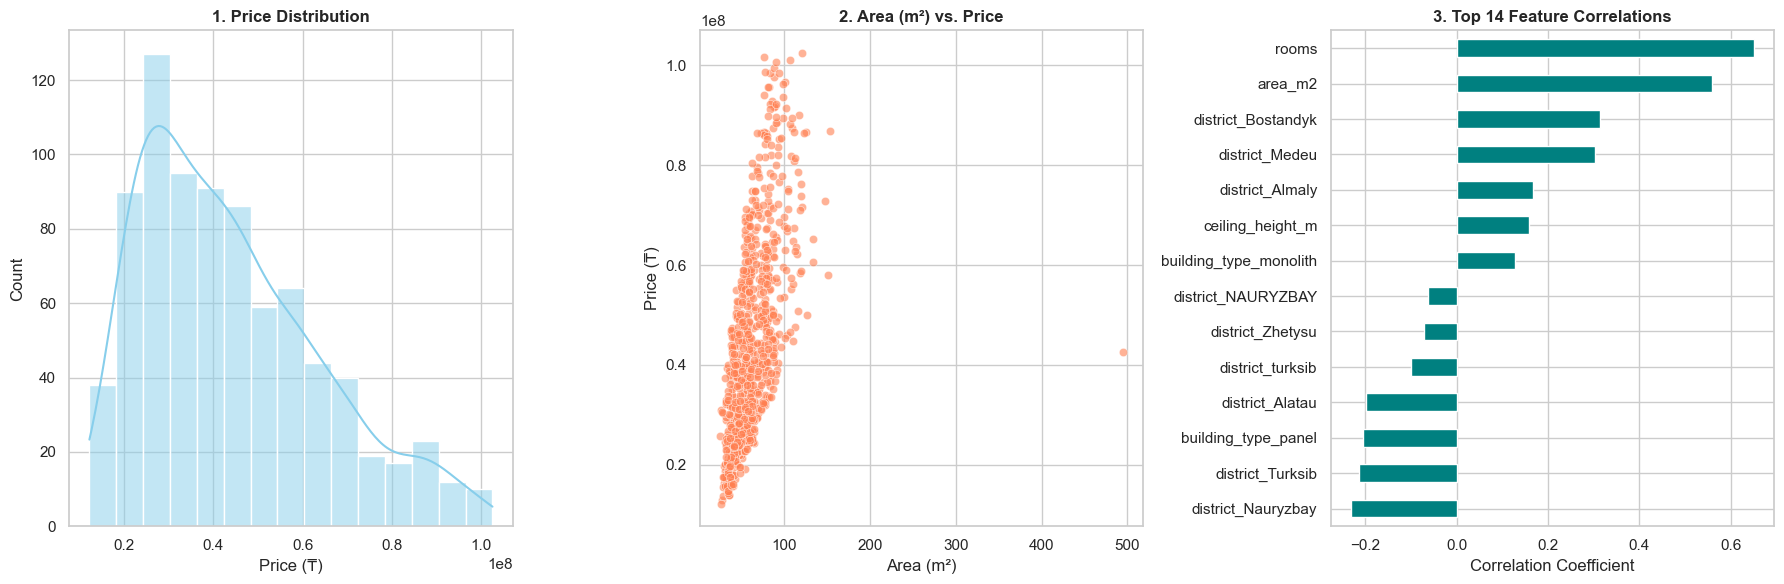

In [11]:
# Step 7: Final EDA, Logging, and Export

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# 1. Save cleaned and processed dataset
output_filename = 'almaty_apartments_clean.csv'
df_ml.to_csv(output_filename, index=False)
print(f"Dataset successfully exported to '{output_filename}'!")

print("\n--- Final Dataset Summary ---")
print(f"Total Rows: {len(df_ml)}")
print(f"Total Features: {df_ml.shape[1]}")

# 2. Create a 3-Panel Visual EDA Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Target Distribution (Price)
sns.histplot(df_imputed['price_kzt'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('1. Price Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (₸)')
axes[0].set_ylabel('Count')

# Plot 2: Relationship (Area vs Price)
sns.scatterplot(data=df_imputed, x='area_m2', y='price_kzt', ax=axes[1], alpha=0.6, color='coral')
axes[1].set_title('2. Area (m²) vs. Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Area (m²)')
axes[1].set_ylabel('Price (₸)')

# Plot 3: Top Correlations with Target
# ИСПРАВЛЕНИЕ: Берем только топ-7 положительных и топ-7 отрицательных корреляций
corr_series = df_ml.corr(numeric_only=True)['price_kzt'].drop('price_kzt')
top_features = pd.concat([corr_series.nlargest(7), corr_series.nsmallest(7)]).sort_values()

top_features.plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('3. Top 14 Feature Correlations', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()